In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("iris.csv")

In [3]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
#check dimensions
df.ndim

2

In [6]:
#check the shape of dataset
df.shape

(150, 5)

In [7]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [9]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(3)

# Univariate Analysis

In [11]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

C:\Users\Admin\AppData\Local\Temp\ipykernel_27576\891408485.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["sepal_length"])


<Axes: xlabel='sepal_length', ylabel='Density'>

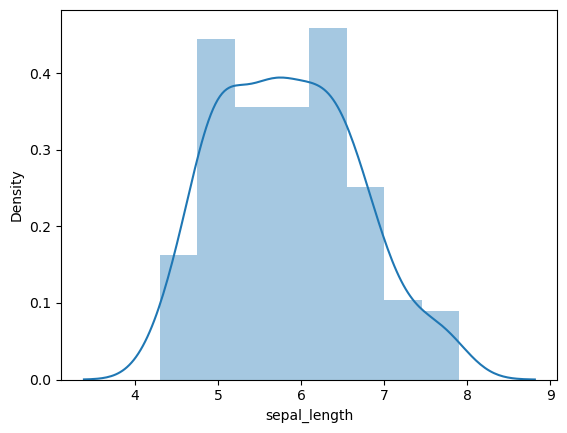

In [12]:
sns.distplot(df["sepal_length"])

In [15]:
#QQ plot
from scipy import stats

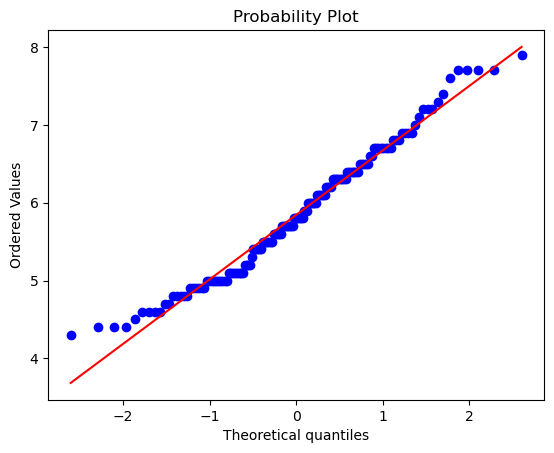

In [16]:
stats.probplot(df["sepal_length"],dist="norm",plot=plt)
plt.show()

In [18]:
from scipy.stats import kstest,anderson

In [22]:
test_stats,p_value=kstest(df["sepal_length"],"norm")

In [23]:
test_stats

np.float64(0.999991460094529)

In [24]:
p_value

np.float64(0.0)

In [25]:
#as per Ks test p_value<0.05 so H0 is rejected thats the reason  
#"sepal_length" is not a Gaussian .

In [29]:
#estimate a CLT to get a population mean of SL
def simulate_clt(data, no_samples, sample_size):
    sample_means=[]
    for i in range(no_samples):
        get_sample=np.random.choice(data, sample_size)
        sample_means.append(np.mean(get_sample))
    return np.mean(sample_means)

In [30]:
data=df["sepal_length"]
no_samples=1000
sample_size=30
simulate_clt(data, no_samples, sample_size)

np.float64(5.849836666666667)

In [35]:
def simulate_bootstrapping(data, sample_size, no_of_samples,CI):
    sample_mean=[]
    for i in range(no_of_samples):
        sample=np.random.choice(data, size=sample_size)
        sample_mean.append(np.mean(sample))
    sample_mean=np.array(sample_mean)
    sorted_means=np.sort(sample_mean)
    per=np.percentile(sorted_means,CI)
    return (sorted_means[0], per)

In [36]:
data=df["sepal_length"]
sample_size=30
no_samples=1000
CI=95
simulate_bootstrapping(data,no_samples,sample_size,CI)

(np.float64(5.7841000000000005), np.float64(5.879875))

In [38]:
def construct_cdf_for_discrete_data(data):
    sorted_data=sorted(data)
    cdf_values=np.arange(1,len(sorted_data)+1)/len(sorted_data)
    return sorted_data,cdf_values

In [39]:
data=df["sepal_length"]
sort_data,cdf_values=construct_cdf_for_discrete_data(data)

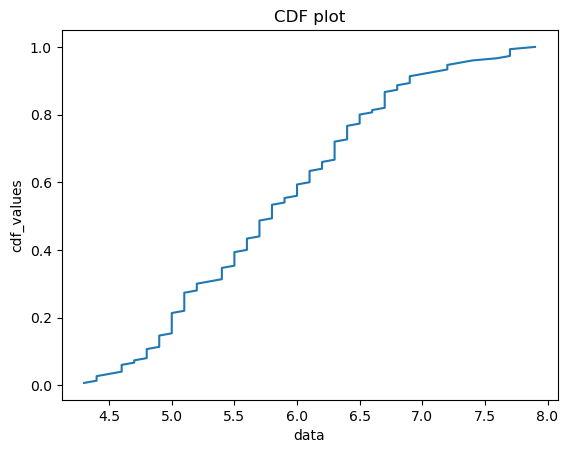

In [41]:
plt.xlabel("data")
plt.ylabel("cdf_values")
plt.title("CDF plot")
plt.plot(sort_data,cdf_values)
plt.show()